In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score
from yellowbrick.classifier import ConfusionMatrix

In [10]:
credito = pd.read_csv("dados/Credit.csv")
credito.head()

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6,'critical/other existing credit',radio/tv,1169,'no known savings',>=7,4,'male single',none,...,'real estate',67,none,own,2,skilled,1,yes,yes,good
1,0<=X<200,48,'existing paid',radio/tv,5951,<100,1<=X<4,2,'female div/dep/mar',none,...,'real estate',22,none,own,1,skilled,1,none,yes,bad
2,'no checking',12,'critical/other existing credit',education,2096,<100,4<=X<7,2,'male single',none,...,'real estate',49,none,own,1,'unskilled resident',2,none,yes,good
3,<0,42,'existing paid',furniture/equipment,7882,<100,4<=X<7,2,'male single',guarantor,...,'life insurance',45,none,'for free',1,skilled,2,none,yes,good
4,<0,24,'delayed previously','new car',4870,<100,1<=X<4,3,'male single',none,...,'no known property',53,none,'for free',2,skilled,2,none,yes,bad


In [11]:
credito.shape

(1000, 21)

In [12]:
#formato de matriz
previsores = credito.iloc[:,0:20].values
classe = credito.iloc[:,20].values

In [13]:
#transformação dos atriutos categóricos em numéricos, passando o indíce em cada coluna categórica
#precisamos criar um objeto para cada atributo categórico, pois na sequ~encia vamos executar o processo de encoding novamente para o registro de teste
#se forem utilizados objetos diferentes, o número atribuído a cada valor será diferente, o que deixará o teste inconstante

labelencoder1 = LabelEncoder()
previsores[:,0] = labelencoder1.fit_transform(previsores[:,0]) 

labelencoder2 = LabelEncoder()
previsores[:,2] = labelencoder2.fit_transform(previsores[:,2]) 

labelencoder3 = LabelEncoder()
previsores[:,3] = labelencoder3.fit_transform(previsores[:,3]) 

labelencoder4 = LabelEncoder()
previsores[:,5] = labelencoder4.fit_transform(previsores[:,5]) 

labelencoder5 = LabelEncoder()
previsores[:,6] = labelencoder5.fit_transform(previsores[:,6]) 

labelencoder6 = LabelEncoder()
previsores[:,8] = labelencoder6.fit_transform(previsores[:,8]) 

labelencoder7 = LabelEncoder()
previsores[:,9] = labelencoder7.fit_transform(previsores[:,9]) 

labelencoder8 = LabelEncoder()
previsores[:,11] = labelencoder8.fit_transform(previsores[:,11]) 

labelencoder9 = LabelEncoder()
previsores[:,13] = labelencoder9.fit_transform(previsores[:,13]) 

labelencoder10 = LabelEncoder()
previsores[:,14] = labelencoder10.fit_transform(previsores[:,14]) 

labelencoder11 = LabelEncoder()
previsores[:,16] = labelencoder11.fit_transform(previsores[:,16]) 

labelencoder12 = LabelEncoder()
previsores[:,18] = labelencoder12.fit_transform(previsores[:,18]) 

labelencoder13 = LabelEncoder()
previsores[:,19] = labelencoder13.fit_transform(previsores[:,19]) 

In [14]:

classe = classe.to_numpy()

In [15]:
#Divisão de bases de dados entre treinamento e teste(30% para teste e 70% para treinamento)
x_treinamento,x_teste,y_treinamento,y_teste = train_test_split( previsores, classe, test_size = 0.3, random_state = 0)
x_teste

array([[2, 36, 3, ..., 1, 1, 1],
       [0, 9, 3, ..., 2, 0, 0],
       [0, 18, 3, ..., 1, 1, 1],
       ...,
       [0, 24, 1, ..., 1, 0, 1],
       [1, 27, 4, ..., 1, 1, 1],
       [1, 12, 3, ..., 1, 0, 1]], shape=(300, 20), dtype=object)

In [16]:
#Criação e treinamento do modelo (geração da tabela de porbabilidade
naive_bayes = GaussianNB()
naive_bayes.fit(x_treinamento,y_treinamento)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[214.,486.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.31,0.69]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[<U4](2,)","['bad','good']"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,0.008194
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,20
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 20)","[[ 1.39,24.75, 2.35,..., 1.17, 0.38, 0.99], [ 0.86,19.26, 2.16,..., 1.14, 0.44, 0.95]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 20)","[[ 0.64,178.25, 1.37,..., 0.15, 0.24, 0.02], [ 0.98,121.37, 1.02,..., 0.13, 0.25, 0.05]]"


In [17]:
#previsões utilizando os registros de teste
previsoes = naive_bayes.predict(x_teste)
previsoes

array(['bad', 'good', 'good', 'good', 'bad', 'good', 'good', 'good',
       'good', 'bad', 'bad', 'bad', 'good', 'bad', 'good', 'good', 'good',
       'good', 'bad', 'good', 'bad', 'good', 'bad', 'good', 'good', 'bad',
       'good', 'good', 'good', 'bad', 'good', 'good', 'good', 'good',
       'good', 'bad', 'good', 'good', 'good', 'good', 'good', 'bad',
       'good', 'good', 'good', 'bad', 'bad', 'bad', 'bad', 'bad', 'good',
       'bad', 'good', 'good', 'good', 'good', 'bad', 'good', 'good',
       'good', 'bad', 'good', 'good', 'good', 'good', 'good', 'good',
       'good', 'bad', 'good', 'good', 'good', 'good', 'good', 'bad',
       'good', 'good', 'good', 'good', 'good', 'good', 'good', 'good',
       'bad', 'good', 'good', 'bad', 'bad', 'good', 'bad', 'good', 'good',
       'good', 'good', 'good', 'good', 'good', 'good', 'good', 'good',
       'good', 'good', 'good', 'bad', 'good', 'good', 'bad', 'bad',
       'good', 'good', 'good', 'bad', 'good', 'good', 'bad', 'good',
      

In [18]:
#geração da matrix de confusão 
confusao = confusion_matrix(y_teste,previsoes)
confusao

array([[ 41,  45],
       [ 42, 172]])

In [19]:
#calculo da taxa de acerto e erro
taxa_acerto = accuracy_score(y_teste,previsoes)
taxa_erro = 1 - taxa_acerto
taxa_acerto

0.71

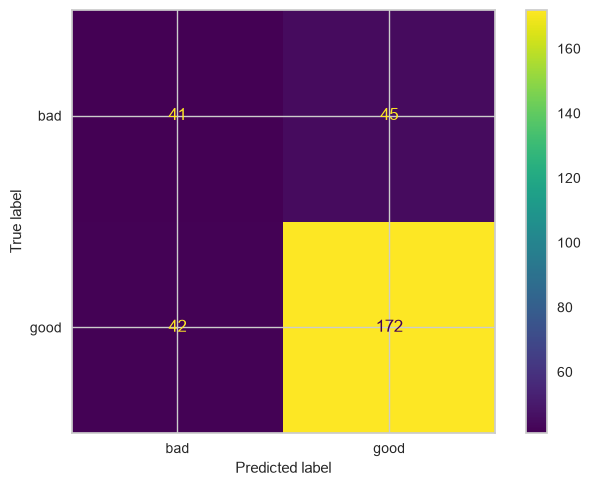

In [20]:
#Visualização da matriz de confusão

from sklearn.metrics import ConfusionMatrixDisplay

modelo = GaussianNB()

modelo.fit(x_treinamento, y_treinamento)

previsoes = modelo.predict(x_teste)

ConfusionMatrixDisplay.from_predictions(y_teste, previsoes)

In [23]:
#Prever um novo registro
nova_previsao = pd.read_csv("dados/NovoCredit.csv")
nova_previsao.shape

(1, 20)

In [24]:
from sklearn.metrics import classification_report

#Gerando um relatório completo de uma vez só (Recomendado):
print(classification_report(y_teste, previsoes))

              precision    recall  f1-score   support

         bad       0.49      0.48      0.49        86
        good       0.79      0.80      0.80       214

    accuracy                           0.71       300
   macro avg       0.64      0.64      0.64       300
weighted avg       0.71      0.71      0.71       300

